In [1]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
from timeit import default_timer as timer
import gropt

In [34]:
def plot_safe(g, gparams, safe_params, safe_params_cardiac, stim_vec=None):
    safe = gropt.gropt_wrapper.get_SAFE(g, gparams.dt, 
                                    safe_params=safe_params)
    safe_cardiac = gropt.gropt_wrapper.get_SAFE(g, gparams.dt, 
                                        safe_params=safe_params_cardiac)
    
    
    print(f'Max SAFE {np.max(safe):.3f}  Max SAFE Cardiac {np.max(safe_cardiac):.3f}')
    plt.figure(figsize=(6,3))
    plt.plot(safe)
    plt.plot(safe_cardiac)
    if stim_vec is not None:
        plt.plot(stim_vec, color='r', alpha=0.5, ls='--')
    plt.show()

In [8]:
[safe_params, safe_params_cardiac] = gropt.readasc.asc_to_safe('C:/Users/mloecher/Downloads/MP_GradSys_P034_X60.asc')

In [7]:
timings_file = '../../private_SAFEdiff/diffusion_timing_parameters_Gmax45.mat'

timings_data = loadmat(timings_file)
T_90 = timings_data['rf_90_duration'][0][0] - timings_data['rf_90_rfCenterInclDelay'][0][0] + timings_data['nav_dur'][0][0]
T_180 = timings_data['rf_180_duration'][0][0] 
sys = timings_data['sys']
dt = 1e-5
T_readout = timings_data['timeToTE'][0][0]

In [9]:
# I dont know what TE/bvalue the target is...
TE = 60e-3

Final Good: True   Solve time: 49.4 ms   N: 219    feval: 6078
Max SAFE 0.545  Max SAFE Cardiac 0.624


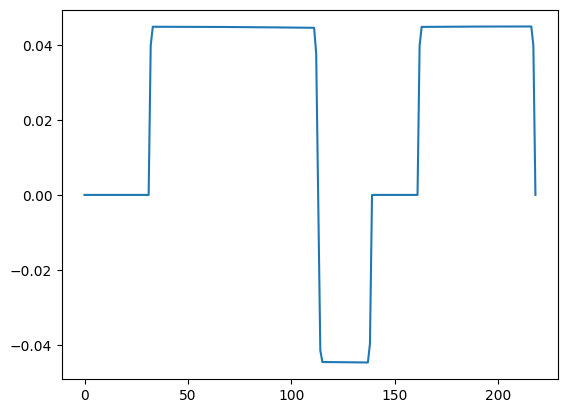

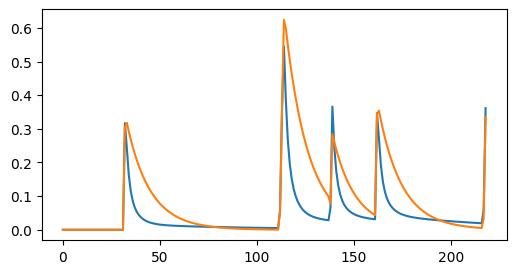

In [10]:
gparams = gropt.GroptParams()
gparams.diff_init(T_90=T_90,
                  T_180=T_180,
                  T_readout=T_readout,
                  TE = 60e-3,
                  dt= 200e-6)

gparams.add_gmax(.045)
gparams.add_smax(200)
gparams.add_moment(0,0.0)
gparams.add_bvalue(496,1)


start_t = timer()

solver = gropt.SolverGroptSDMM()
solver.set_general_params(max_iter=30000, max_feval = 100000)
solver.solve(gparams)
out = gparams.get_out()

stop_t = timer()
print(f'Final Good: {gparams.final_good>0}   Solve time: {1000*(stop_t-start_t):.1f} ms   N: {out.size}    feval: {gparams.final_n_feval}')

plt.figure()
plt.plot(out)

plot_safe(out, gparams, safe_params, safe_params_cardiac)

Final Good: True   Solve time: 111.8 ms   N: 219    feval: 4777
Max SAFE 0.544  Max SAFE Cardiac 0.622


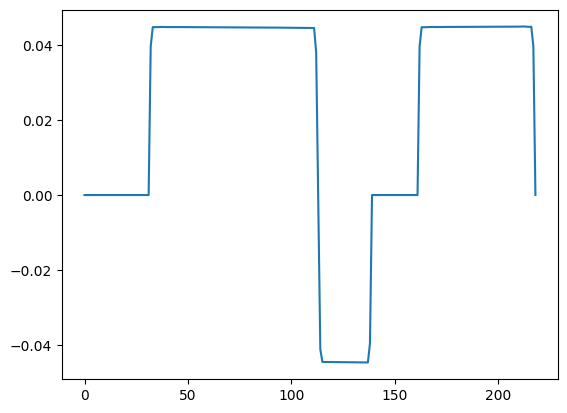

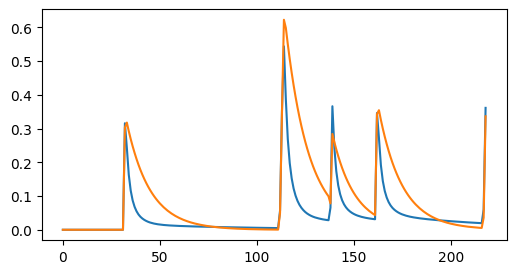

In [11]:
gparams = gropt.GroptParams()
gparams.diff_init(T_90=T_90,
                  T_180=T_180,
                  T_readout=T_readout,
                  TE = 60e-3,
                  dt= 200e-6)

gparams.add_gmax(.045)
gparams.add_smax(200)
gparams.add_moment(0,0.0)
gparams.add_bvalue(496,1)

gparams.add_SAFE(1.0,safe_params=safe_params)
gparams.add_SAFE(1, safe_params=safe_params_cardiac)


start_t = timer()

solver = gropt.SolverGroptSDMM()
solver.set_general_params(max_iter=30000, max_feval = 100000)
solver.solve(gparams)
out = gparams.get_out()

stop_t = timer()
print(f'Final Good: {gparams.final_good>0}   Solve time: {1000*(stop_t-start_t):.1f} ms   N: {out.size}    feval: {gparams.final_n_feval}')

plt.figure()
plt.plot(out)

plot_safe(out, gparams, safe_params, safe_params_cardiac)

In [13]:
timings_file = '../../private_SAFEdiff/diffusion_timing_parameters_Gmax200.mat'

timings_data = loadmat(timings_file)
T_90 = timings_data['rf_90_duration'][0][0] - timings_data['rf_90_rfCenterInclDelay'][0][0] + timings_data['nav_dur'][0][0]
T_180 = timings_data['rf_180_duration'][0][0] 
sys = timings_data['sys']
dt = 1e-5
T_readout = timings_data['timeToTE'][0][0]

Final Good: True   Solve time: 28.8 ms   N: 233    feval: 6441
Max SAFE 1.048  Max SAFE Cardiac 2.127


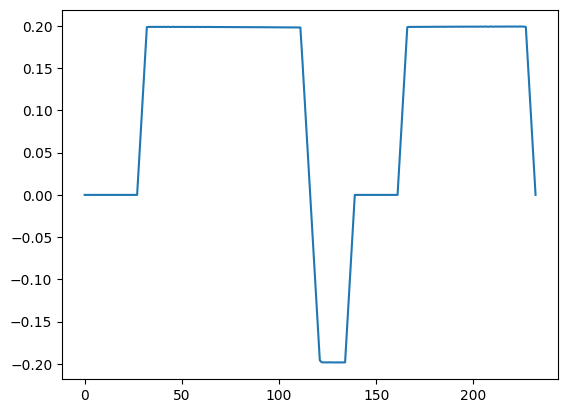

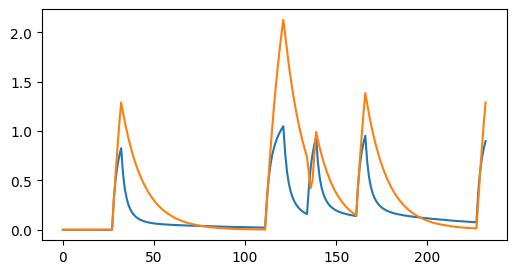

In [14]:
gparams = gropt.GroptParams()
gparams.diff_init(T_90=T_90,
                  T_180=T_180,
                  T_readout=T_readout,
                  TE = 60e-3,
                  dt= 200e-6)

gparams.add_gmax(.2)
gparams.add_smax(200)
gparams.add_moment(0,0.0)
gparams.add_bvalue(12400,1)

# gparams.add_SAFE(1.0,safe_params=safe_params)
# gparams.add_SAFE(1, safe_params=safe_params_cardiac)


start_t = timer()

solver = gropt.SolverGroptSDMM()
solver.set_general_params(max_iter=30000, max_feval = 100000)
solver.solve(gparams)
out = gparams.get_out()

stop_t = timer()
print(f'Final Good: {gparams.final_good>0}   Solve time: {1000*(stop_t-start_t):.1f} ms   N: {out.size}    feval: {gparams.final_n_feval}')

plt.figure()
plt.plot(out)

plot_safe(out, gparams, safe_params, safe_params_cardiac)

Final Good: True   Solve time: 749.7 ms   N: 233    feval: 24907
Max SAFE 0.895  Max SAFE Cardiac 0.991


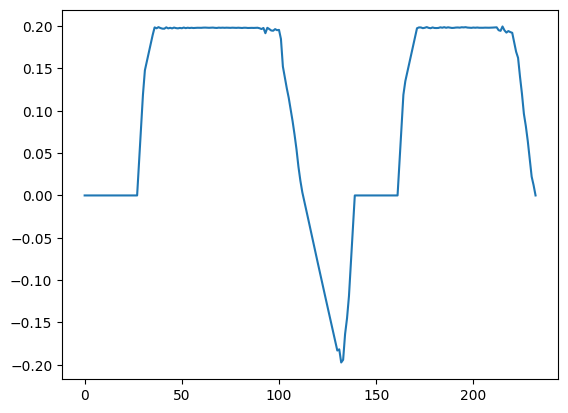

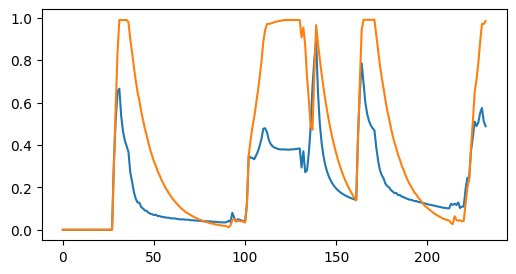

In [15]:
gparams = gropt.GroptParams()
gparams.diff_init(T_90=T_90,
                  T_180=T_180,
                  T_readout=T_readout,
                  TE = 60e-3,
                  dt = 200e-6)

gparams.add_gmax(.2)
gparams.add_smax(200)
gparams.add_moment(0,0.0)
gparams.add_bvalue(10900,1)

gparams.add_SAFE(1.0, safe_params=safe_params)
gparams.add_SAFE(1.0, safe_params=safe_params_cardiac)


start_t = timer()

solver = gropt.SolverGroptSDMM()
solver.set_general_params(max_iter=30000, max_feval = 100000)
solver.set_ils_params(ils_max_iter=3, ils_tol=0.1, ils_sigma=.001)
solver.set_sdmm_params(rw_interval = 64, grw_interval=100)
solver.solve(gparams)
out = gparams.get_out()

stop_t = timer()
print(f'Final Good: {gparams.final_good>0}   Solve time: {1000*(stop_t-start_t):.1f} ms   N: {out.size}    feval: {gparams.final_n_feval}')

plt.figure()
plt.plot(out)

plot_safe(out, gparams, safe_params, safe_params_cardiac)

Final Good: True   Solve time: 1629.6 ms   N: 117    feval: 118559
Max SAFE 0.882  Max SAFE Cardiac 0.992


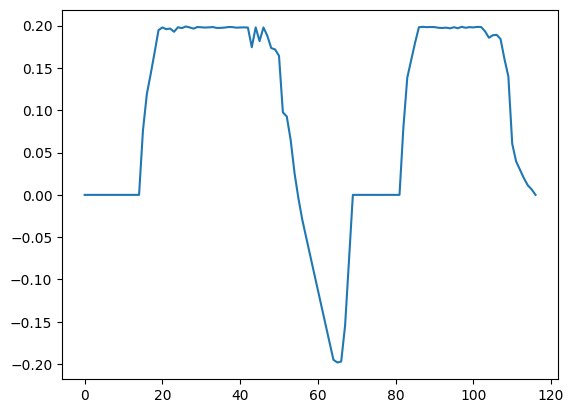

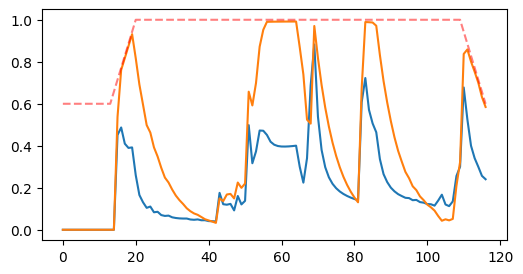

In [63]:
gparams = gropt.GroptParams()
gparams.diff_init(T_90=T_90,
                  T_180=T_180,
                  T_readout=T_readout,
                  TE = 60e-3,
                  dt = 400e-6)

gparams.add_gmax(.2)
gparams.add_smax(200)
gparams.add_moment(0,0.0)
gparams.add_bvalue(8900,1)

stim_vec = 1.0*np.ones(gparams.N)
d_stim = 8
stim_vec[:int(T_90//gparams.dt)] = 0.6
stim_vec[int(T_90//gparams.dt):int(T_90//gparams.dt)+d_stim] = np.linspace(0.6, 1.0, d_stim)
stim_vec[-d_stim:] = np.linspace(1,0.6,d_stim)

gparams.add_SAFE_vec(stim_vec, safe_params=safe_params)
gparams.add_SAFE_vec(stim_vec, safe_params=safe_params_cardiac)

start_t = timer()

solver = gropt.SolverGroptSDMM()
solver.set_general_params(max_iter=30000, max_feval = 200000)
solver.set_ils_params(ils_max_iter=3, ils_tol=0.1, ils_sigma=.001, ils_tik_lam=.001)
solver.set_sdmm_params(rw_interval = 64, grw_interval=100)
solver.solve(gparams)
out = gparams.get_out()

stop_t = timer()
print(f'Final Good: {gparams.final_good>0}   Solve time: {1000*(stop_t-start_t):.1f} ms   N: {out.size}    feval: {gparams.final_n_feval}')

plt.figure()
plt.plot(out)

plot_safe(out, gparams, safe_params, safe_params_cardiac, stim_vec)

In [33]:
stim_vec.shape

(233,)

In [17]:
T_90//gparams.dt


np.float64(26.0)